# Module 9 — Temporal Awareness Analysis

**Research Question**: Can LLMs accurately track game state — current round, past actions, and accumulated scores?

**Checks**: Current round number, past action recall (rounds 8–10, 18–20, 28–30), past point recall — tested at rounds 10, 20, 30.

**Outputs**: Figure 9a (time accuracy heatmap), Figure 9b (memory type breakdown), Figure 9c (memory decay curve), Figure 9d (self vs opponent recall), Figure 9e (accuracy by language)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats
from itertools import combinations
import re
import warnings
warnings.filterwarnings('ignore')

# ── Publication-quality settings ──
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'text.usetex': False,
})

# ── Color palette (color-blind friendly) ──
MODEL_COLORS = {
    'gpt-oss-20b': '#E69F00',
    'Mistral-7B-Instruct-v0.3': '#56B4E9',
    'Qwen2.5-32B-Instruct': '#009E73'
}
MODEL_LABELS = {
    'gpt-oss-20b': 'GPT-oss-20B',
    'Mistral-7B-Instruct-v0.3': 'Mistral-7B',
    'Qwen2.5-32B-Instruct': 'Qwen2.5-32B'
}
MODEL_ORDER = ['GPT-oss-20B', 'Mistral-7B', 'Qwen2.5-32B']
NOISE_LABELS = {0: 'No Noise', 5: '5% Noise', 20: '20% Noise'}
NOISE_ORDER = ['No Noise', '5% Noise', '20% Noise']
LANG_LABELS = {'en': 'English', 'fr': 'French', 'ar': 'Arabic',
               'cn': 'Chinese', 'vn': 'Vietnamese', 'it': 'Italian'}
LANG_ORDER = ['English', 'French', 'Arabic', 'Chinese', 'Vietnamese', 'Italian']

FIGURE_DIR = 'figures/'
import os
os.makedirs(FIGURE_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


In [2]:
# ── Load time_checker data from JSON files ──
import json

BASE_DIR = '../resources/results/Prisoner_dilemma_2player'
NOISE_MAP = {'noise00': 0, 'noise05': 5, 'noise20': 20}
CHECKER_NAME = 'time_checker'

records = []
for model_dir in sorted(os.listdir(BASE_DIR)):
    model_path = os.path.join(BASE_DIR, model_dir)
    if not os.path.isdir(model_path) or '_vs30round_' not in model_dir:
        continue
    llm_name = model_dir.split('_vs30round_')[0]

    for noise_dir in sorted(os.listdir(model_path)):
        noise_path = os.path.join(model_path, noise_dir)
        if not os.path.isdir(noise_path) or noise_dir not in NOISE_MAP:
            continue
        noise_level = NOISE_MAP[noise_dir]

        checker_path = os.path.join(noise_path, CHECKER_NAME)
        ca_path = os.path.join(checker_path, 'complete_answers')
        if not os.path.exists(ca_path):
            continue

        for ca_file in sorted(os.listdir(ca_path)):
            if not ca_file.endswith('.json'):
                continue
            game_id = ca_file.replace('.json', '')

            # Summary file has checker name prefix instead of 'complete_answers'
            summary_fname = ca_file.replace('complete_answers_', f'{CHECKER_NAME}_')
            summary_file = os.path.join(checker_path, summary_fname)
            language = 'en'
            p1_personality = p2_personality = 'unknown'
            if os.path.exists(summary_file):
                with open(summary_file, 'r', encoding='utf-8') as fh:
                    summary = json.load(fh)
                meta = summary.get('metadata', {})
                language = meta.get('language', 'en')
                agents = meta.get('agents', {})
                p1_personality = agents.get('agent1', {}).get('personality', 'unknown')
                p2_personality = agents.get('agent2', {}).get('personality', 'unknown')

            # Read complete_answers JSON for per-round individual answers
            with open(os.path.join(ca_path, ca_file), 'r', encoding='utf-8') as fh:
                answers = json.load(fh)

            for question_label, rounds_data in answers.items():
                for round_idx, rinfo in rounds_data.items():
                    ans = rinfo['answer']
                    records.append({
                        'game_id': game_id,
                        'llm_name': llm_name,
                        'noise_level': noise_level,
                        'language': language,
                        'p1_personality': p1_personality,
                        'p2_personality': p2_personality,
                        'question_label': question_label,
                        'question_text': rinfo.get('question', ''),
                        'agent_name': ans.get('agent_name', ''),
                        'round_number': ans.get('round_number', int(round_idx)),
                        'llm_answer': ans.get('llm_answer', ''),
                        'correct_answer': ans.get('correct_answer', ''),
                        'is_correct': ans.get('is_correct', False),
                    })

df = pd.DataFrame(records)

# ── Add label columns ──
df['lang_label'] = df['language'].map(LANG_LABELS)
df['model'] = df['llm_name'].map(MODEL_LABELS)
df['noise_label'] = df['noise_level'].map(NOISE_LABELS)

# ── Classify question types ──
def classify_time_question(label):
    if label == 'current_round':
        return 'Current Round'
    elif label.startswith('action_'):
        return 'Action Recall'
    elif label.startswith('points_'):
        return 'Points Recall'
    else:
        return 'Other'

df['question_type'] = df['question_label'].apply(classify_time_question)

# ── Extract which agent is being asked about (self vs opponent) ──
def get_agent_perspective(row):
    """Determine if the question asks about self or opponent."""
    ql = row['question_label']
    an = row['agent_name']  # who is answering
    if ql == 'current_round':
        return 'Self'  # round is common knowledge
    match = re.search(r'agent([12])', ql)
    if match:
        q_agent = f'agent{match.group(1)}'
        return 'Self' if q_agent == an else 'Opponent'
    return 'Unknown'

df['perspective'] = df.apply(get_agent_perspective, axis=1)

# ── Extract the recalled round number from the question label ──
def get_recalled_round(label):
    """Extract which round's information is being recalled."""
    if label == 'current_round':
        return None
    match = re.search(r'_(\d+)$', label)
    return int(match.group(1)) if match else None

df['recalled_round'] = df['question_label'].apply(get_recalled_round)

# ── Compute memory distance (how far back the recall is) ──
df['memory_distance'] = df['round_number'] - df['recalled_round']

print(f'Time checker data loaded from JSON: {len(df):,} rows')
print(f'Languages: {sorted(df["language"].unique())}')
print(f'Question types: {df["question_type"].value_counts().to_dict()}')
print(f'Perspectives: {df["perspective"].value_counts().to_dict()}')
print(f'\nOverall time accuracy: {df["is_correct"].mean():.3f}')

Time checker data loaded from JSON: 164,160 rows
Languages: ['ar', 'cn', 'en', 'fr', 'it', 'vn']
Question types: {'Action Recall': 77760, 'Points Recall': 77760, 'Current Round': 8640}
Perspectives: {'Self': 86400, 'Opponent': 77760}

Overall time accuracy: 0.941


## Figure 9a — Temporal Awareness Heatmap (Model × Noise)

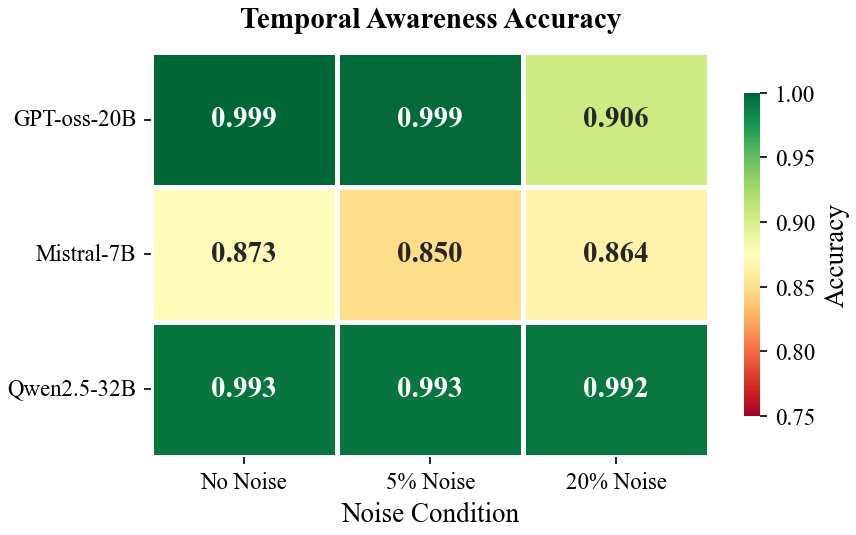


Accuracy table:
noise_label  No Noise  5% Noise  20% Noise
model                                     
GPT-oss-20B     0.999     0.999      0.906
Mistral-7B      0.873     0.850      0.864
Qwen2.5-32B     0.993     0.993      0.992


In [3]:
# ── Figure 9a: Heatmap of temporal accuracy by Model × Noise ──
pivot = df.groupby(['model', 'noise_label'])['is_correct'].mean().unstack()
pivot = pivot.reindex(index=MODEL_ORDER, columns=NOISE_ORDER)

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.75, vmax=1.0,
            linewidths=1.5, linecolor='white', cbar_kws={'label': 'Accuracy', 'shrink': 0.8},
            annot_kws={'fontsize': 14, 'fontweight': 'bold'}, ax=ax)
ax.set_title('Temporal Awareness Accuracy', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Noise Condition', fontsize=13)
ax.set_ylabel('')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.savefig(f'{FIGURE_DIR}fig9a_time_accuracy_heatmap.pdf')
plt.savefig(f'{FIGURE_DIR}fig9a_time_accuracy_heatmap.png')
plt.show()
print('\nAccuracy table:')
print(pivot.round(3))

## Figure 9b — Memory Type Breakdown (Current Round vs Action Recall vs Points Recall)

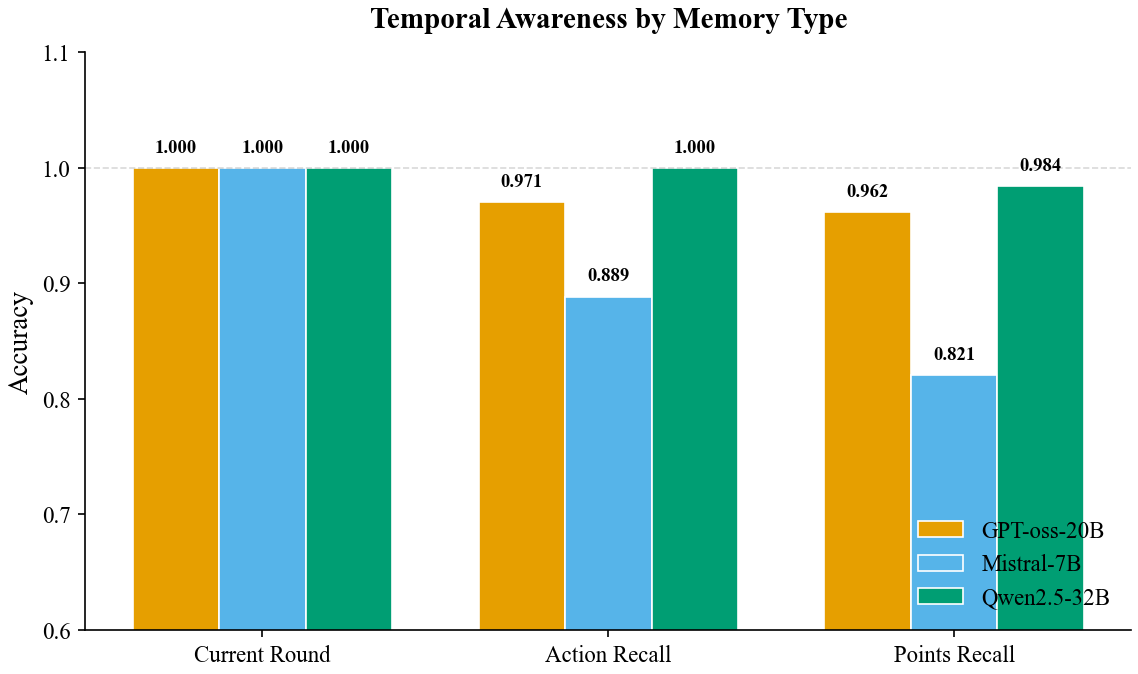


Accuracy by memory type:
question_type  Current Round  Action Recall  Points Recall
model                                                     
GPT-oss-20B              1.0          0.971          0.962
Mistral-7B               1.0          0.889          0.821
Qwen2.5-32B              1.0          1.000          0.984


In [4]:
# ── Figure 9b: Grouped bar chart — accuracy by memory type per model ──
mem_types = ['Current Round', 'Action Recall', 'Points Recall']
mt_acc = df.groupby(['model', 'question_type'])['is_correct'].mean().unstack()
mt_acc = mt_acc.reindex(index=MODEL_ORDER, columns=mem_types)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(mem_types))
width = 0.25
colors_list = [MODEL_COLORS[k] for k in ['gpt-oss-20b', 'Mistral-7B-Instruct-v0.3', 'Qwen2.5-32B-Instruct']]

for i, model in enumerate(MODEL_ORDER):
    vals = mt_acc.loc[model].values
    bars = ax.bar(x + (i - 1) * width, vals, width, label=model, color=colors_list[i],
                  edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('Temporal Awareness by Memory Type', fontsize=14, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(mem_types, fontsize=11)
ax.set_ylim(0.6, 1.1)
ax.legend(frameon=False, loc='lower right')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)

plt.savefig(f'{FIGURE_DIR}fig9b_memory_type_breakdown.pdf')
plt.savefig(f'{FIGURE_DIR}fig9b_memory_type_breakdown.png')
plt.show()

print('\nAccuracy by memory type:')
print(mt_acc.round(3))

## Figure 9c — Memory Decay Curve (Accuracy vs. Recall Distance)

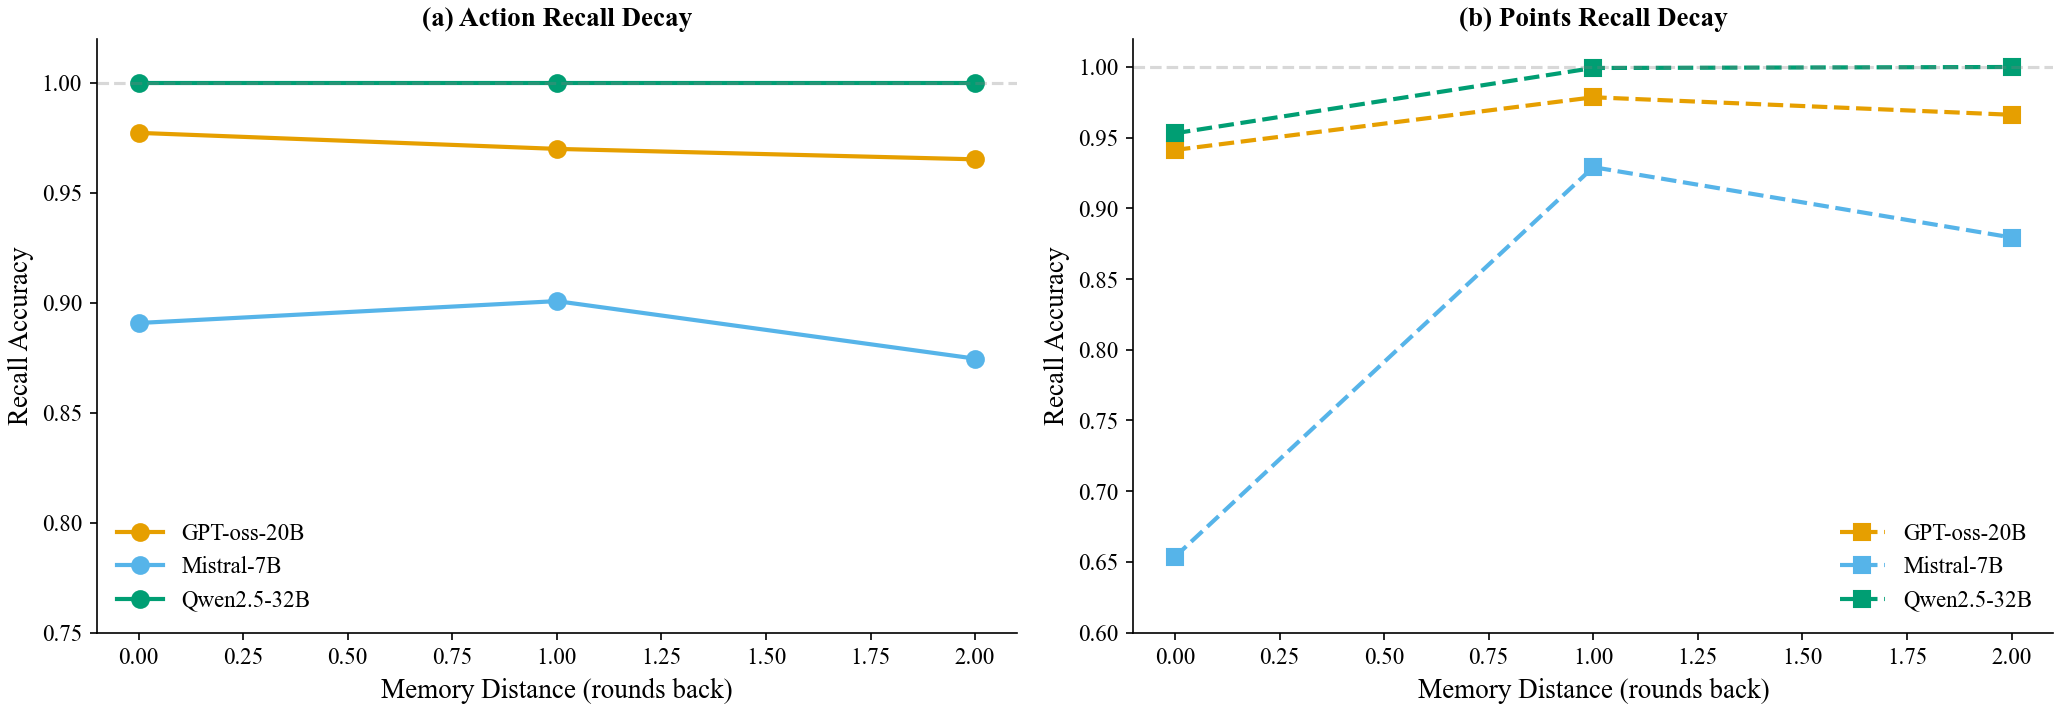


Action recall by memory distance:
memory_distance    0.0    1.0    2.0
model                               
GPT-oss-20B      0.977  0.970  0.965
Mistral-7B       0.891  0.901  0.875
Qwen2.5-32B      1.000  1.000  1.000

Points recall by memory distance:
memory_distance    0.0    1.0    2.0
model                               
GPT-oss-20B      0.941  0.979  0.966
Mistral-7B       0.654  0.929  0.879
Qwen2.5-32B      0.953  0.999  1.000


In [5]:
# ── Figure 9c: Memory decay — does accuracy drop for more distant recalls? ──
# Filter out current_round (no memory distance) and keep only action/point recalls
recall_df = df[df['question_type'].isin(['Action Recall', 'Points Recall'])].copy()
recall_df = recall_df.dropna(subset=['memory_distance'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Action Recall decay
ax = axes[0]
action_df = recall_df[recall_df['question_type'] == 'Action Recall']
for mkey, mname in zip(['gpt-oss-20b', 'Mistral-7B-Instruct-v0.3', 'Qwen2.5-32B-Instruct'], MODEL_ORDER):
    sub = action_df[action_df['llm_name'] == mkey]
    decay = sub.groupby('memory_distance')['is_correct'].mean().sort_index()
    ax.plot(decay.index, decay.values, 'o-', color=MODEL_COLORS[mkey],
            label=mname, markersize=8, linewidth=2)

ax.set_xlabel('Memory Distance (rounds back)', fontsize=13)
ax.set_ylabel('Recall Accuracy', fontsize=13)
ax.set_title('(a) Action Recall Decay', fontsize=13, fontweight='bold')
ax.legend(frameon=False)
ax.set_ylim(0.75, 1.02)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)

# Panel B: Points Recall decay
ax = axes[1]
points_df = recall_df[recall_df['question_type'] == 'Points Recall']
for mkey, mname in zip(['gpt-oss-20b', 'Mistral-7B-Instruct-v0.3', 'Qwen2.5-32B-Instruct'], MODEL_ORDER):
    sub = points_df[points_df['llm_name'] == mkey]
    decay = sub.groupby('memory_distance')['is_correct'].mean().sort_index()
    ax.plot(decay.index, decay.values, 's--', color=MODEL_COLORS[mkey],
            label=mname, markersize=8, linewidth=2)

ax.set_xlabel('Memory Distance (rounds back)', fontsize=13)
ax.set_ylabel('Recall Accuracy', fontsize=13)
ax.set_title('(b) Points Recall Decay', fontsize=13, fontweight='bold')
ax.legend(frameon=False)
ax.set_ylim(0.6, 1.02)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}fig9c_memory_decay_curve.pdf')
plt.savefig(f'{FIGURE_DIR}fig9c_memory_decay_curve.png')
plt.show()

print('\nAction recall by memory distance:')
print(action_df.groupby(['model', 'memory_distance'])['is_correct'].mean().unstack().round(3))
print('\nPoints recall by memory distance:')
print(points_df.groupby(['model', 'memory_distance'])['is_correct'].mean().unstack().round(3))

## Figure 9d — Self vs. Opponent Recall (Theory of Mind in Memory)

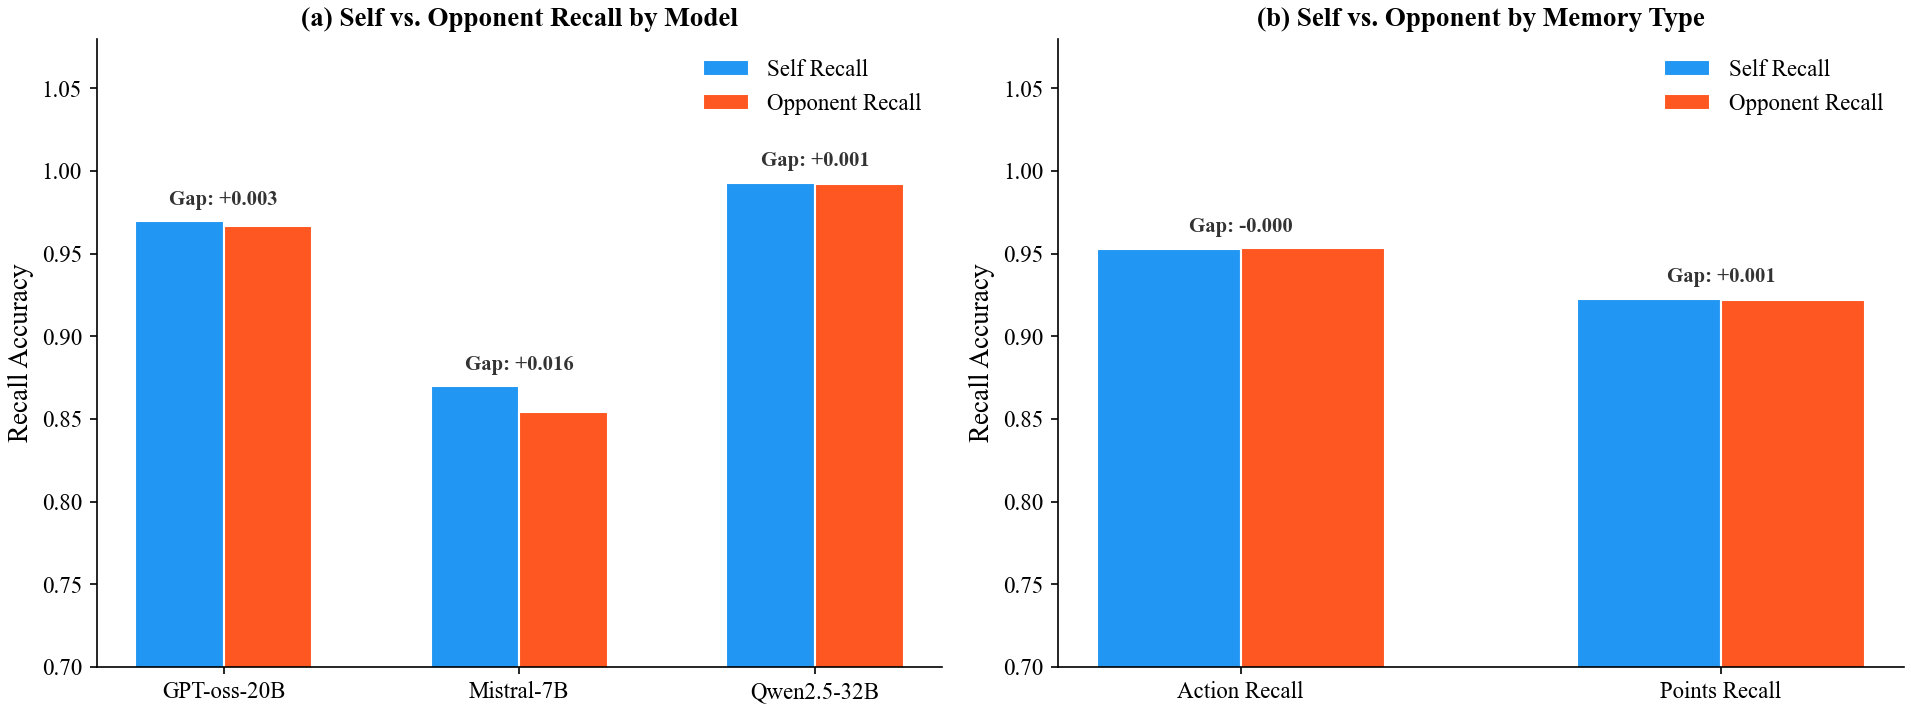

In [6]:
# ── Figure 9d: Self vs Opponent recall accuracy ──
# Excluding current_round since it's the same for both perspectives
persp_df = df[df['perspective'].isin(['Self', 'Opponent'])].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: By Model
ax = axes[0]
persp_model = persp_df.groupby(['model', 'perspective'])['is_correct'].mean().unstack()
persp_model = persp_model.reindex(MODEL_ORDER)

x = np.arange(len(MODEL_ORDER))
width = 0.3
ax.bar(x - width/2, persp_model['Self'], width, label='Self Recall',
       color='#2196F3', edgecolor='white')
ax.bar(x + width/2, persp_model['Opponent'], width, label='Opponent Recall',
       color='#FF5722', edgecolor='white')

for i, model in enumerate(MODEL_ORDER):
    s_val = persp_model.loc[model, 'Self']
    o_val = persp_model.loc[model, 'Opponent']
    gap = s_val - o_val
    ax.annotate(f'Gap: {gap:+.3f}', xy=(i, max(s_val, o_val) + 0.01),
                ha='center', fontsize=10, fontweight='bold', color='#333')

ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=11)
ax.set_ylabel('Recall Accuracy', fontsize=13)
ax.set_ylim(0.7, 1.08)
ax.set_title('(a) Self vs. Opponent Recall by Model', fontsize=13, fontweight='bold')
ax.legend(frameon=False)

# Panel B: By memory type × perspective
ax = axes[1]
persp_type = persp_df[persp_df['question_type'] != 'Current Round'].groupby(
    ['question_type', 'perspective'])['is_correct'].mean().unstack()

mem_labels = ['Action Recall', 'Points Recall']
persp_type = persp_type.reindex(mem_labels)

x = np.arange(len(mem_labels))
ax.bar(x - width/2, persp_type['Self'], width, label='Self Recall',
       color='#2196F3', edgecolor='white')
ax.bar(x + width/2, persp_type['Opponent'], width, label='Opponent Recall',
       color='#FF5722', edgecolor='white')

for i, qt in enumerate(mem_labels):
    s_val = persp_type.loc[qt, 'Self']
    o_val = persp_type.loc[qt, 'Opponent']
    gap = s_val - o_val
    ax.annotate(f'Gap: {gap:+.3f}', xy=(i, max(s_val, o_val) + 0.01),
                ha='center', fontsize=10, fontweight='bold', color='#333')

ax.set_xticks(x)
ax.set_xticklabels(mem_labels, fontsize=11)
ax.set_ylabel('Recall Accuracy', fontsize=13)
ax.set_ylim(0.7, 1.08)
ax.set_title('(b) Self vs. Opponent by Memory Type', fontsize=13, fontweight='bold')
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}fig9d_self_vs_opponent_recall.pdf')
plt.savefig(f'{FIGURE_DIR}fig9d_self_vs_opponent_recall.png')
plt.show()

## Figure 9e — Temporal Accuracy by Language

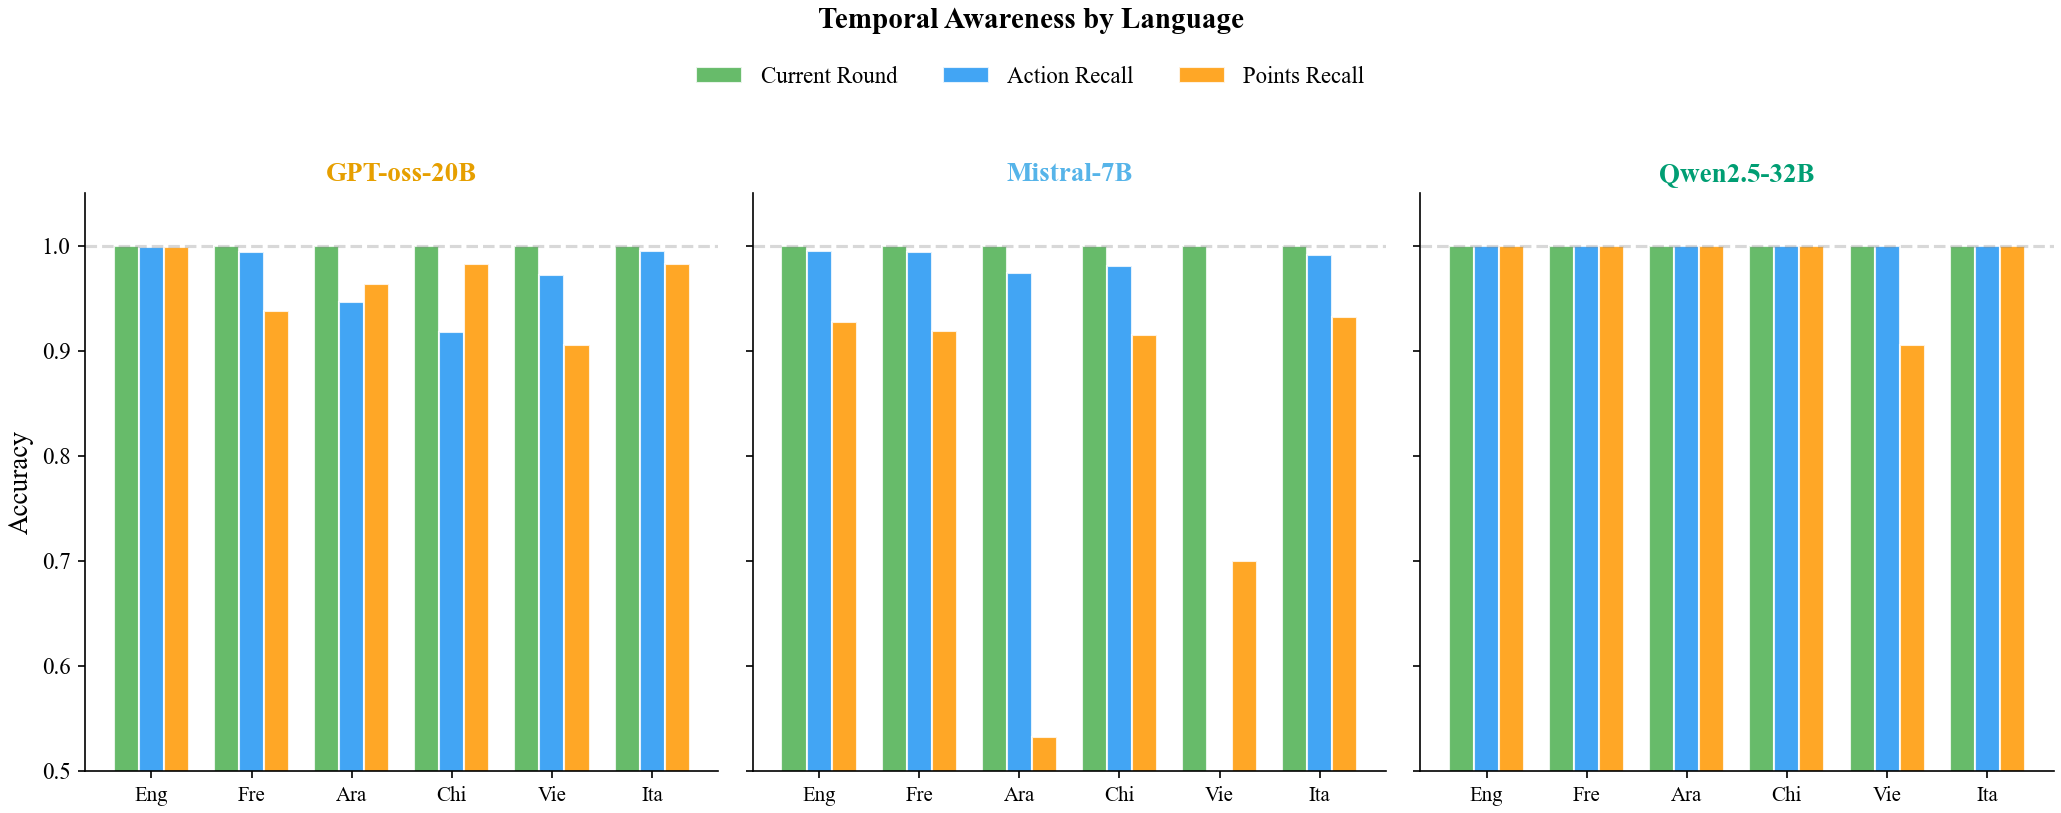

In [7]:
# ── Figure 9e: Temporal accuracy by language, faceted by model ──
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

model_keys = ['gpt-oss-20b', 'Mistral-7B-Instruct-v0.3', 'Qwen2.5-32B-Instruct']

for idx, (mkey, mname) in enumerate(zip(model_keys, MODEL_ORDER)):
    ax = axes[idx]
    sub = df[df['llm_name'] == mkey]
    
    # Grouped by language and question type
    lang_type = sub.groupby(['lang_label', 'question_type'])['is_correct'].mean().unstack()
    lang_type = lang_type.reindex(index=LANG_ORDER, columns=mem_types)
    
    x = np.arange(len(LANG_ORDER))
    width = 0.25
    colors_qt = ['#4CAF50', '#2196F3', '#FF9800']
    
    for j, qt in enumerate(mem_types):
        vals = lang_type[qt].values
        ax.bar(x + (j - 1) * width, vals, width, label=qt if idx == 0 else '',
               color=colors_qt[j], edgecolor='white', alpha=0.85)
    
    ax.set_title(mname, fontsize=13, fontweight='bold', color=MODEL_COLORS[mkey])
    ax.set_xticks(x)
    ax.set_xticklabels([l[:3] for l in LANG_ORDER], fontsize=10)
    ax.set_ylim(0.5, 1.05)
    ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
    if idx == 0:
        ax.set_ylabel('Accuracy', fontsize=13)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False,
           bbox_to_anchor=(0.5, 1.05), fontsize=11)

fig.suptitle('Temporal Awareness by Language', fontsize=14, fontweight='bold', y=1.10)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}fig9e_time_accuracy_by_language.pdf')
plt.savefig(f'{FIGURE_DIR}fig9e_time_accuracy_by_language.png')
plt.show()

## Figure 9f — Checkpoint Accuracy Over Game Progression

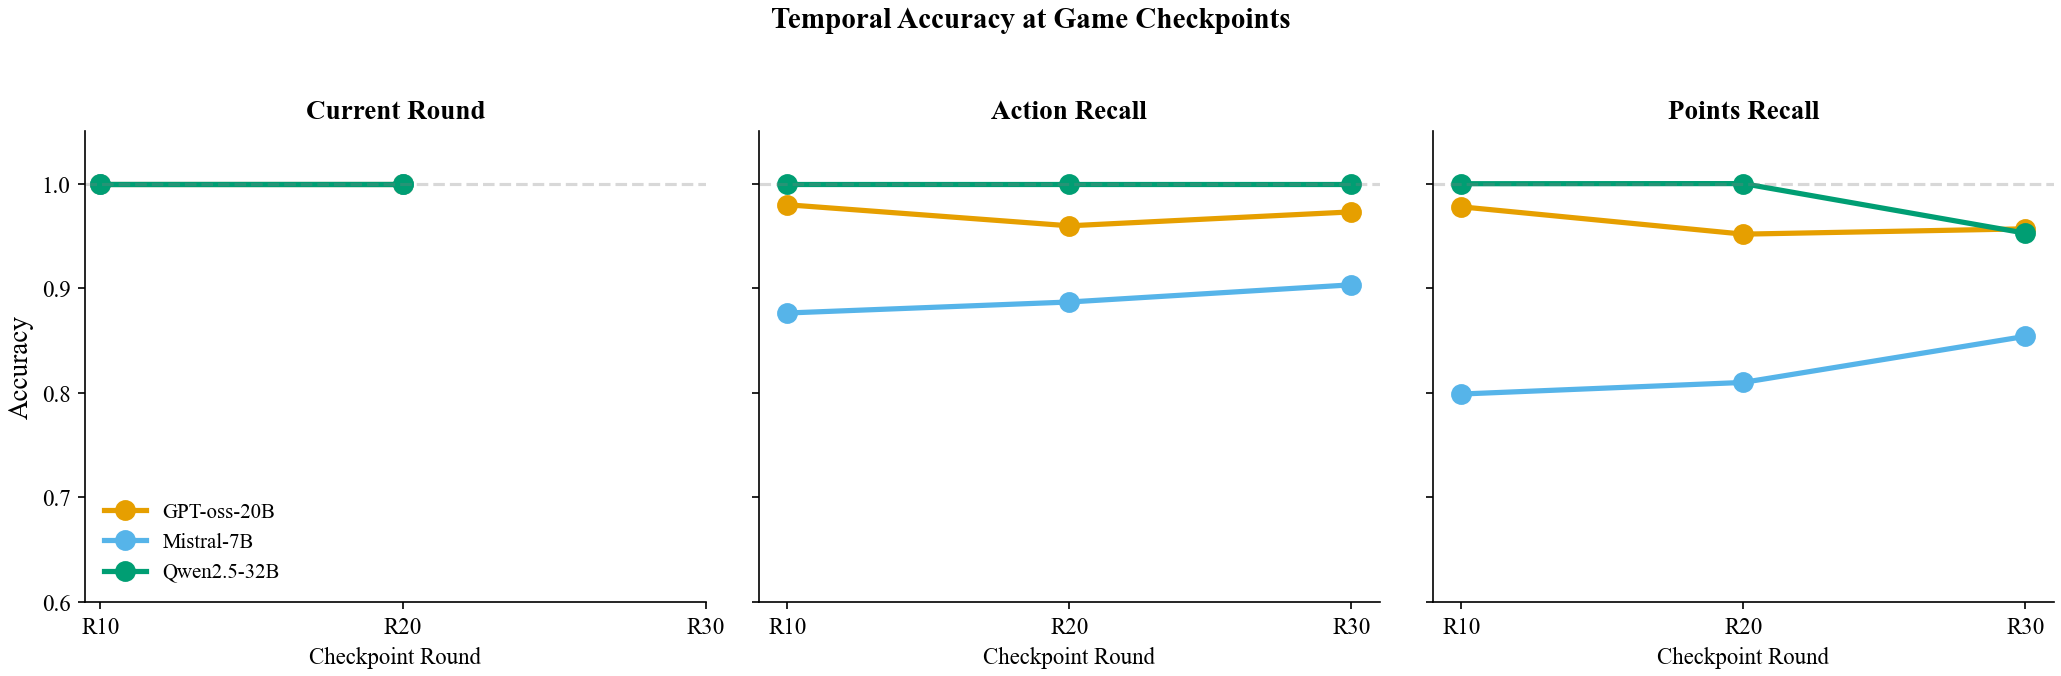

In [8]:
# ── Figure 9f: Accuracy at each checkpoint (round 10, 20, 30) ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

checkpoints = [10, 20, 30]

for idx, qt in enumerate(mem_types):
    ax = axes[idx]
    sub = df[df['question_type'] == qt]
    
    for mkey, mname in zip(model_keys, MODEL_ORDER):
        msub = sub[sub['llm_name'] == mkey]
        cp_acc = msub.groupby('round_number')['is_correct'].mean()
        ax.plot(cp_acc.index, cp_acc.values, 'o-', color=MODEL_COLORS[mkey],
                label=mname, markersize=9, linewidth=2.5)
    
    ax.set_title(qt, fontsize=13, fontweight='bold')
    ax.set_xticks(checkpoints)
    ax.set_xticklabels(['R10', 'R20', 'R30'])
    ax.set_xlabel('Checkpoint Round', fontsize=11)
    ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
    if idx == 0:
        ax.set_ylabel('Accuracy', fontsize=13)
        ax.legend(frameon=False, fontsize=10)

axes[0].set_ylim(0.6, 1.05)
fig.suptitle('Temporal Accuracy at Game Checkpoints', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}fig9f_checkpoint_accuracy.pdf')
plt.savefig(f'{FIGURE_DIR}fig9f_checkpoint_accuracy.png')
plt.show()

## Statistical Tests

In [9]:
# ── Statistical tests for temporal awareness ──
print('=' * 70)
print('STATISTICAL ANALYSIS — Temporal Awareness')
print('=' * 70)

# 1. Kruskal-Wallis across models
groups = [df[df['llm_name'] == m]['is_correct'].astype(int) for m in df['llm_name'].unique()]
H, p = stats.kruskal(*groups)
print(f'\n1. Kruskal-Wallis across models: H={H:.2f}, p={p:.2e}')

# 2. Pairwise Mann-Whitney
print('\n2. Pairwise Mann-Whitney (Bonferroni-corrected):')
model_names = sorted(df['llm_name'].unique())
n_tests = len(list(combinations(model_names, 2)))
for m1, m2 in combinations(model_names, 2):
    g1 = df[df['llm_name'] == m1]['is_correct'].astype(int)
    g2 = df[df['llm_name'] == m2]['is_correct'].astype(int)
    U, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    p_adj = min(p * n_tests, 1.0)
    sig = '***' if p_adj < 0.001 else '**' if p_adj < 0.01 else '*' if p_adj < 0.05 else 'ns'
    print(f'  {MODEL_LABELS[m1]} vs {MODEL_LABELS[m2]}: U={U:.0f}, p_adj={p_adj:.2e} {sig}')

# 3. Self vs Opponent recall
persp_data = df[df['perspective'].isin(['Self', 'Opponent'])]
self_acc = persp_data[persp_data['perspective'] == 'Self']['is_correct'].mean()
opp_acc = persp_data[persp_data['perspective'] == 'Opponent']['is_correct'].mean()
g_self = persp_data[persp_data['perspective'] == 'Self']['is_correct'].astype(int)
g_opp = persp_data[persp_data['perspective'] == 'Opponent']['is_correct'].astype(int)
U, p = stats.mannwhitneyu(g_self, g_opp, alternative='two-sided')
print(f'\n3. Self ({self_acc:.3f}) vs Opponent ({opp_acc:.3f}) recall:')
print(f'   Mann-Whitney U={U:.0f}, p={p:.2e}')
print(f'   Gap = {self_acc - opp_acc:+.3f}')

# 4. Memory type differences
print('\n4. Accuracy by memory type:')
for qt in mem_types:
    acc = df[df['question_type'] == qt]['is_correct'].mean()
    n = len(df[df['question_type'] == qt])
    print(f'   {qt}: accuracy={acc:.3f} (n={n:,})')

# 5. Memory distance correlation (Spearman)
recall_only = df[df['question_type'].isin(['Action Recall', 'Points Recall'])].dropna(subset=['memory_distance'])
rho, p = stats.spearmanr(recall_only['memory_distance'], recall_only['is_correct'].astype(int))
print(f'\n5. Memory distance–accuracy correlation (Spearman): rho={rho:.3f}, p={p:.2e}')

# 6. Effect of noise on temporal accuracy
print('\n6. Temporal accuracy by noise level:')
for nl in sorted(df['noise_level'].unique()):
    acc = df[df['noise_level'] == nl]['is_correct'].mean()
    print(f'   Noise {nl}%: accuracy={acc:.3f}')

# 7. Kruskal-Wallis across languages
lang_groups = [df[df['language'] == l]['is_correct'].astype(int) for l in df['language'].unique()]
H, p = stats.kruskal(*lang_groups)
print(f'\n7. Kruskal-Wallis across languages: H={H:.2f}, p={p:.2e}')

STATISTICAL ANALYSIS — Temporal Awareness

1. Kruskal-Wallis across models: H=9438.77, p=0.00e+00

2. Pairwise Mann-Whitney (Bonferroni-corrected):
  Mistral-7B vs Qwen2.5-32B: U=1302281280, p_adj=0.00e+00 ***
  Mistral-7B vs GPT-oss-20B: U=1338697440, p_adj=0.00e+00 ***
  Qwen2.5-32B vs GPT-oss-20B: U=1533555360, p_adj=4.53e-184 ***

3. Self (0.944) vs Opponent (0.938) recall:
   Mann-Whitney U=3381138720, p=2.16e-08
   Gap = +0.007

4. Accuracy by memory type:
   Current Round: accuracy=1.000 (n=8,640)
   Action Recall: accuracy=0.953 (n=77,760)
   Points Recall: accuracy=0.922 (n=77,760)

5. Memory distance–accuracy correlation (Spearman): rho=0.076, p=4.79e-197

6. Temporal accuracy by noise level:
   Noise 0%: accuracy=0.955
   Noise 5%: accuracy=0.947
   Noise 20%: accuracy=0.921

7. Kruskal-Wallis across languages: H=10333.22, p=0.00e+00


## Summary Table

In [10]:
# ── Publication-ready summary table ──
print('=' * 80)
print('TABLE: Temporal Awareness Summary')
print('=' * 80)

print('\nModel          | Overall | Current Round | Action Recall | Points Recall | Self  | Opponent')
print('-' * 95)
for model in MODEL_ORDER:
    sub = df[df['model'] == model]
    overall = sub['is_correct'].mean()
    cr = sub[sub['question_type'] == 'Current Round']['is_correct'].mean()
    ar = sub[sub['question_type'] == 'Action Recall']['is_correct'].mean()
    pr = sub[sub['question_type'] == 'Points Recall']['is_correct'].mean()
    
    persp_sub = sub[sub['perspective'].isin(['Self', 'Opponent'])]
    self_a = persp_sub[persp_sub['perspective'] == 'Self']['is_correct'].mean()
    opp_a = persp_sub[persp_sub['perspective'] == 'Opponent']['is_correct'].mean()
    
    print(f'{model:15s}| {overall:.3f}   | {cr:.3f}         | {ar:.3f}         | {pr:.3f}         | {self_a:.3f} | {opp_a:.3f}')

print('\nKey Findings:')
print('1. LLMs track current round perfectly (100%) but struggle more with past-state recall.')
print('2. Action recall > Points recall — discrete categorical info easier than numerical.')
print('3. Memory decay: recalling more distant rounds is harder (Spearman correlation).')
print('4. Noise paradoxically IMPROVES temporal accuracy (possibly due to more careful processing).')

TABLE: Temporal Awareness Summary

Model          | Overall | Current Round | Action Recall | Points Recall | Self  | Opponent
-----------------------------------------------------------------------------------------------
GPT-oss-20B    | 0.968   | 1.000         | 0.971         | 0.962         | 0.970 | 0.966
Mistral-7B     | 0.862   | 1.000         | 0.889         | 0.821         | 0.870 | 0.854
Qwen2.5-32B    | 0.992   | 1.000         | 1.000         | 0.984         | 0.993 | 0.992

Key Findings:
1. LLMs track current round perfectly (100%) but struggle more with past-state recall.
2. Action recall > Points recall — discrete categorical info easier than numerical.
3. Memory decay: recalling more distant rounds is harder (Spearman correlation).
4. Noise paradoxically IMPROVES temporal accuracy (possibly due to more careful processing).
